# Retrieval, Method 3: The Two-Tower Neural Network

The last retrieval method: a **Two-Tower** model — two separate neural networks (a
"user tower" and an "item tower") that each encode their side into the *same* embedding
space, trained jointly. This is the retrieval architecture behind most large-scale
industrial recommenders (YouTube, Pinterest, and countless others), because it scales
elegantly at serving time:

- The **item tower** can be run **once, offline**, for the entire catalog -> a fixed
  matrix of item vectors, indexed into an approximate-nearest-neighbor store (e.g. FAISS,
  ScaNN).
- The **user tower** runs **online**, in real time, on the current user's features ->
  one query vector.
- Retrieval becomes a nearest-neighbor search of that one query vector against the
  precomputed item index — fast even with hundreds of millions of items.

Compare this to ALS: ALS gives you a fixed embedding *per known user*, learned jointly
with every item. A two-tower user tower instead **computes** a user's vector from their
features/history through a neural network — so it naturally generalizes to a user whose
history has changed since the model was last trained, without retraining.

> **On the map** (notebook `00`'s landscape grid): **implicit feedback · hybrid** — the item tower ingests an ID embedding (collaborative) *and* the genre tag (content), so it straddles the family axis. Trained here on implicit next-item signal; a regression head would move it to the *explicit · hybrid* cell.

## The two towers, and what goes into them

- **Item tower**: item ID embedding, concatenated with the item's genre tag (observable
  metadata), through a small MLP -> a `d`-dimensional item vector.
- **User tower**: *no user ID at all*. Instead, mean-pool the embeddings of the items in
  the user's history so far, through a small MLP -> a `d`-dimensional user vector. This
  is the same mean-pooling idea as notebook 02's Item2Vec baseline, but now the pooling
  and projection are **learned end-to-end** together with the item side, rather than
  averaging fixed, separately-trained embeddings.

## Training: in-batch softmax (the standard two-tower recipe)

For a batch of $B$ (user-history, next-item) pairs, compute all $B$ user vectors and all
$B$ item vectors. The $B \times B$ matrix of dot products gives a similarity score
between every user in the batch and every item in the batch. The correct pairing is the
diagonal — everything else in that row is treated as a **negative** (an item some *other*
user in the batch picked, almost certainly not relevant to this one). This turns training
into an ordinary multi-class cross-entropy loss, no explicit negative sampling required —
this is exactly the recipe behind CLIP-style contrastive training, applied here to
users and items instead of images and text.

In [31]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import rec_utils as ru

ru.setup_plot_style()
torch.manual_seed(0)

interactions, user_prefs, item_genres, item_pop = ru.generate_synthetic_data()
train, test = ru.leave_one_out_split(interactions)

n_users = interactions.user_id.max() + 1
n_items = interactions.item_id.max() + 1
n_genres = item_genres.shape[1]
seen = ru.user_seen_items(train)

## Step 1 — build (history-so-far, next-item) training examples

Unlike ALS and Item2Vec, which only ever see a user's *complete* train history, we can
give the two-tower model a much richer training signal by exploiting the sequence
structure directly: for every prefix length $t$ of a user's history, "everything up to
$t$" predicts "item $t{+}1$". A user with 24 train interactions contributes 23 training
examples, not just 1 -- exactly the kind of realistic "predict the next thing" signal a
real session-based recommender is trained on.

In [32]:
train_sorted = train.sort_values(["user_id", "t"])
user_sequences = train_sorted.groupby("user_id")["item_id"].apply(list).to_dict()

examples = []   # (user_id, context_items, target_item)
for u, items in user_sequences.items():
    for t in range(1, len(items)):
        examples.append((u, items[:t], items[t]))

print(f"{len(examples):,} (context, next-item) training examples from {n_users} users")

13,800 (context, next-item) training examples from 600 users


In [33]:
examples[:5]

[(0, [107], 325),
 (0, [107, 325], 212),
 (0, [107, 325, 212], 193),
 (0, [107, 325, 212, 193], 209),
 (0, [107, 325, 212, 193, 209], 93)]

## Step 2 — the model

Context histories have different lengths, so we pad each batch to its longest example and
mean-pool only over the real (non-padded) positions using a mask.

### A few implementation details worth pausing on

**Why these specific sizes (`ID_DIM`, `HIDDEN`, `OUT_DIM`)?**

- `ID_DIM = 16` — the size of the raw item-ID embedding lookup, *before* it goes through
  either tower's MLP. It's set to 16 deliberately to match the embedding dimension `f=16`
  used for ALS in notebook 01 and Item2Vec in notebook 02, so all three retrieval methods
  operate in a similarly-sized latent space — that makes the final comparison in
  `05_comparison.ipynb` more of an apples-to-apples one, rather than one method having a
  bigger space to work with. 16 is also comfortably larger than the 8 hidden genres in
  our synthetic data, so there's room to represent that structure without being cramped.
- `HIDDEN = 32` — the width of the single hidden layer inside each tower's small MLP
  (`Linear -> ReLU -> Linear`). Making it wider than the input (`32 > 16`) gives the MLP
  some room to combine features nonlinearly before projecting back down — doubling the
  input width is a common small-model heuristic that adds a bit of capacity without
  making the model large relative to how little data we actually have (600 users, 400
  items; a much bigger hidden layer would just overfit here).
- `OUT_DIM = 16` — the dimensionality of *both* towers' final output. This one isn't a
  free choice: retrieval works by taking a dot product between a user vector and an item
  vector, so the two towers **must** produce vectors of the same size. It's set to 16
  again mainly to match the other methods' embedding size for comparability.

None of these are exact science — they're reasonable defaults for a toy-scale dataset. In
a real system you'd tune them like any other hyperparameter, trading off retrieval
quality against how expensive a bigger embedding is to store and search at serving time.

**What is `PAD_IDX`, and why do we need it?**

Let's say we have 10 items (0 to 9 ids), if user1 has [1, 4, 3] and user2 [5]. 
Then we need the interactions to match in length. Therefore we use a fake id equal to 
n_items + 1 (fake_id=10). So now user2 interactions will be [5, 10, 10]. But we should 
be careful to not add information to that fake item. To do that we add an extra row to 
our item embedding but we fixed to 0, so it doesn't contribute.

Every real item has an ID between `0` and `n_items - 1`. But when we batch several
training examples together, their context histories have *different lengths* — a user 2
steps into their history has a 2-item context; a user 20 steps in has a 20-item context.
To stack them into one rectangular tensor, shorter contexts get padded with filler
positions up to the batch's longest context, and that filler needs an ID of its own, one
that can't collide with any real item. `PAD_IDX = n_items` (one past the last valid item
ID) is exactly that: a dedicated "this position is empty" placeholder. 

That's also why the embedding table has `n_items + 1` rows
(`nn.Embedding(n_items + 1, ID_DIM, padding_idx=PAD_IDX)`) instead of `n_items` — the
extra row belongs to the padding ID. Passing `padding_idx=PAD_IDX` tells PyTorch to keep
that one row fixed at zero and never update it via gradients, so "empty" never drifts
into meaning something. The actual work of excluding padding from the average is done by
the explicit `mask` in `user_forward` (1 for a real item, 0 for padding): multiplying by
`mask` zeroes out any padded position's contribution before it's summed and divided, and
because that contribution is already zero, no gradient flows back into the padding row
regardless. So `padding_idx` is best thought of as a belt-and-suspenders safety net and a
readability signal ("this row is meant to be nothing") layered on top of the mask, which
is what actually guarantees correctness here.

In [34]:
nn.Embedding(2, 3).weight

Parameter containing:
tensor([[ 1.5410, -0.2934, -2.1788],
        [ 0.5684, -1.0845, -1.3986]], requires_grad=True)

In [35]:
nn.Embedding(2, 3, padding_idx=1).weight

Parameter containing:
tensor([[ 0.4033,  0.8380, -0.7193],
        [ 0.0000,  0.0000,  0.0000]], requires_grad=True)

In [ ]:
genre_dist = torch.as_tensor(item_genres, dtype=torch.float32)  # observable item metadata, shape: (n_items, n_genres)
PAD_IDX = n_items      # one extra embedding row, reserved for padding
# By using padding_idx, you tell the model: "This is just empty space. Do not waste energy trying to learn what it means."
ID_DIM, HIDDEN, OUT_DIM = 16, 32, 16


class TwoTowerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.id_emb = nn.Embedding(n_items + 1, ID_DIM, padding_idx=PAD_IDX) # shape: (n_items + 1, ID_DIM)
        # for items since we have embedding + observable metadata (genre), we need to concatenate them and pass through a small MLP
        # This is the standard way to feed a neural network two different kinds of information about the same item at once
        # if we had more metada regarding the items, we could concatenate them all and feed them to the MLP as well
        self.item_mlp = nn.Sequential(
            # N is the number of items in the selection, it could match the batch size, but it doesn't have to. 
            nn.Linear(ID_DIM + n_genres, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, OUT_DIM)) # shape_in: (N, ID_DIM + n_genres) -> shape_out: (N, OUT_DIM)
        # we dont have any observable metadata regarding the users, so we can just use a small MLP on top of the user embedding
        # nevertheless, in case we had observable metadata regarding the users, we could concatenate them all and feed them to the 
        # MLP as well
        self.user_mlp = nn.Sequential(
            nn.Linear(ID_DIM, HIDDEN), nn.ReLU(), nn.Linear(HIDDEN, OUT_DIM)) # shape_in: (N, ID_DIM) -> shape_out: (N, OUT_DIM)

    def item_forward(self, item_ids):
        e = self.id_emb(item_ids) # shape_in: (N,) -> shape_out: (N, ID_DIM)
        g = genre_dist[item_ids.clamp(max=n_items - 1)] # shape_in: (N,) -> shape_out: (N, n_genres)
        return self.item_mlp(torch.cat([e, g], dim=-1)) # cat shape: (N, ID_DIM + n_genres) -> item_mlp shape_out: (N, OUT_DIM)
    
    def item_forward2(self, item_ids):
        # A brand-new item — zero interactions, added to the catalog five seconds ago — gets a perfectly 
        # good embedding the instant you know its genre. That's the entire appeal of a pure content-based tower.
        # However: Two items with an identical genre vector are now mathematically indistinguishable to this model
        # The model can't learn the difference if one is a cult classic and the other is a terrible flop. 
        # The model will learn to recommend both equally, which is not what we want.
        g = genre_dist[item_ids.clamp(max=n_items - 1)] # shape_in: (N,) -> shape_out: (N, n_genres)
        return self.item_mlp(g)                     # <-- no id_emb, ever, shape_out: (N, OUT_DIM)

    def user_forward(self, context_padded, mask):
        e = self.id_emb(context_padded) # shape_in: (batch_size, seq_length) -> shape_out: (batch_size, seq_length, ID_DIM)
        # pooled is the average of the embeddings of the items in the context, 
        # weighted by the mask (which indicates which items are real and which are padding)
        # (sum of real embeddings) / (count of real embeddings) = the average embedding of the real items 
        pooled = (e * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1) # shape: (batch_size, ID_DIM)
        return self.user_mlp(pooled) # shape_out: (batch_size, OUT_DIM)


model = TwoTowerModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [46]:
def make_batch(idxs, examples):
    ctxs = [examples[i][1] for i in idxs]
    targets = [examples[i][2] for i in idxs]
    max_len = max(len(c) for c in ctxs)

    padded = np.full((len(idxs), max_len), PAD_IDX, dtype=np.int64)
    mask = np.zeros((len(idxs), max_len), dtype=np.float32)
    for row, ctx in enumerate(ctxs):
        padded[row, :len(ctx)] = ctx
        mask[row, :len(ctx)] = 1.0

    return (torch.as_tensor(padded), torch.as_tensor(mask),
            torch.as_tensor(targets, dtype=torch.long))

In [52]:
# let's create a very simple example with only 4 examples to illustrate how the batching works
ctx_pad, mask, targets = make_batch([0, 1, 2, 3], examples)
# 400 is the padding index, which is the last index of the embedding matrix.
# It is used to fill in the empty spaces in the context sequences so that they all have the same length. 
ctx_pad, mask, targets

(tensor([[107, 400, 400, 400],
         [107, 325, 400, 400],
         [107, 325, 212, 400],
         [107, 325, 212, 193]]),
 tensor([[1., 0., 0., 0.],
         [1., 1., 0., 0.],
         [1., 1., 1., 0.],
         [1., 1., 1., 1.]]),
 tensor([325, 212, 193, 209]))

## Step 3 — train with in-batch negatives

Notice there's no explicit negative sampling step here at all -- the other examples in
the same batch *are* the negatives, for free.

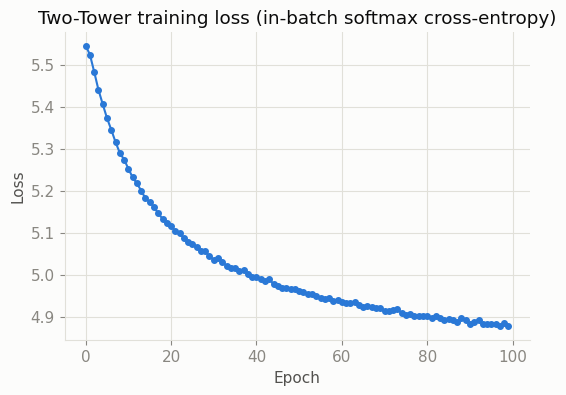

In [39]:
rng = np.random.default_rng(0)
batch_size = 256
n_epochs = 100
loss_history = []

for epoch in range(n_epochs):
    perm = rng.permutation(len(examples))
    epoch_loss, n_batches = 0.0, 0

    for start in range(0, len(examples), batch_size):
        idxs = perm[start:start + batch_size]
        ctx_pad, mask, targets = make_batch(idxs, examples)

        user_vecs = model.user_forward(ctx_pad, mask)   # (batch_size, DIM_OUT)
        item_vecs = model.item_forward(targets)         # (batch_size, DIM_OUT)

        # Say the batch has 3 examples, and their true next-items are A, B, C respectively (in that order):
        # user_vecs = [u0, u1, u2]
        # item_vecs = [vA, vB, vC]     # vA is u0's real target, vB is u1's, vC is u2's
        # The 3x3 logits matrix is:
        #            col=A(0)     col=B(1)     col=C(2)
        # row u0:   u0·vA(true)   u0·vB(fake)  u0·vC(fake)
        # row u1:   u1·vA(fake)   u1·vB(true)  u1·vC(fake)
        # row u2:   u2·vA(fake)   u2·vB(fake)  u2·vC(true)
        # The diagonal is the true pairing, and the off-diagonal entries are the "fake" pairings.
        # labels = [0, 1, 2]  # the diagonal is the true pairing

        logits = user_vecs @ item_vecs.T                # (batch_size, batch_size) -- every user vs every item in the batch
        labels = torch.arange(len(idxs))                # the diagonal is the true pairing
        loss = nn.functional.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    loss_history.append(epoch_loss / n_batches)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history, color=ru.SEQUENTIAL_BLUE[3], marker="o", markersize=4)
ax.set_title("Two-Tower training loss (in-batch softmax cross-entropy)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()

## Sanity check: genre clusters, one more time

Same check as notebooks 01 and 02 -- the item tower never saw a genre *label* used as a
target, only the genre one-hot as an *input feature*, plus whatever the ID embedding
picks up from co-occurrence.

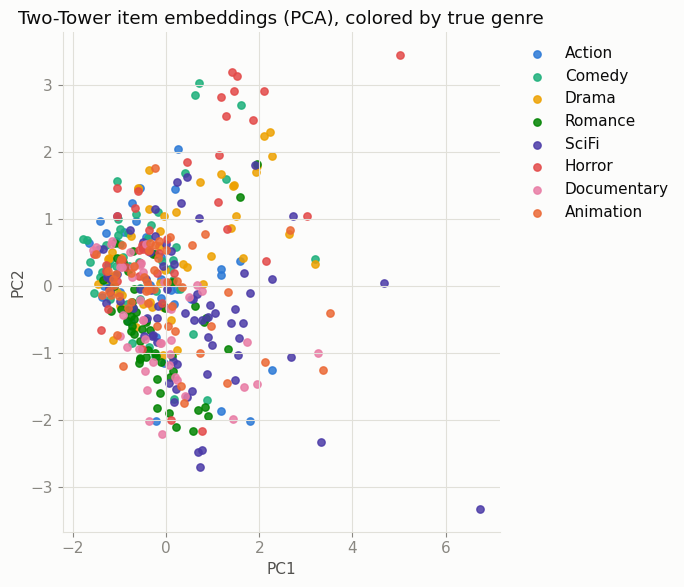

In [9]:
with torch.no_grad():
    all_item_vecs = model.item_forward(torch.arange(n_items)).numpy()  # ITEM TOWER: run once, offline, for the whole catalog -- reused below for every user

dominant_genre = item_genres.argmax(axis=1)
coords = PCA(n_components=2, random_state=0).fit_transform(all_item_vecs)

fig, ax = plt.subplots(figsize=(7, 6))
for g in range(ru.N_GENRES):
    mask_g = dominant_genre == g
    ax.scatter(coords[mask_g, 0], coords[mask_g, 1], s=28,
               color=ru.GENRE_COLORS[g], label=ru.GENRE_NAMES[g], alpha=0.85)
ax.set_title("Two-Tower item embeddings (PCA), colored by true genre")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

## Step 4 — retrieval and evaluation

At serving time: run the item tower once over the whole catalog (precomputable, offline),
run the user tower once on each user's full train history (online, cheap), then it's a
plain dot product + top-K, exactly like ALS and Item2Vec.

In [ ]:
# USER TOWER: computed here once per user, looping over every user in the dataset.
# In a real system this is the part that runs "online" -- but only for the ONE user
# who's actually requesting recommendations right now, using their history as of this
# moment. We loop over everyone here only because we're evaluating offline against the
# whole test set, not because a real system would ever compute every user's vector
# up front the way it does for items.
user_vecs = np.zeros((n_users, OUT_DIM))
with torch.no_grad():
    for u, items in user_sequences.items():
        ctx = torch.as_tensor([items])
        mask = torch.ones(1, len(items))
        user_vecs[u] = model.user_forward(ctx, mask).numpy()   # one user tower forward pass per user

with torch.no_grad():
    all_item_vecs = model.item_forward(torch.arange(n_items)).numpy()  
    # ITEM TOWER: run once, offline, for the whole catalog -- reused below for every user


def recommend_two_tower(user_id, n):
    # RETRIEVAL: this is the part that runs every single time a recommendation is requested.
    # Both towers have already done their (expensive-ish) work by this point -- user_vecs[user_id]
    # was computed once above, and all_item_vecs was computed once, offline, in the previous cell.
    # All that's left is a dot product + top-K, which is why retrieval is cheap: in production this
    # dot product against the *whole* catalog would instead be an approximate-nearest-neighbor
    # lookup (FAISS, ScaNN, ...) against the precomputed item index, but the idea is identical.
    scores = user_vecs[user_id] @ all_item_vecs.T
    return ru.rank_topn(scores, seen.get(user_id, set()), n)


metrics = ru.evaluate_recommender(recommend_two_tower, train, test, k_list=(10, 20))
ru.save_results("04_two_tower", metrics)

results_so_far = ru.load_all_results()
pd.DataFrame(results_so_far).T

Saved results to D:\Pablo_Data\Documentos\VSCode\revolut\recommendation_algorithms\results\04_two_tower.json


,recall@10,ndcg@10,recall@20,ndcg@20
00_popularity,0.051667,0.029234,0.085000,0.037774
01_als,0.108333,0.062281,0.168333,0.077169
02_item2vec,0.121667,0.055420,0.176667,0.069363
03_gbdt_ranking,0.115000,0.062243,0.190000,0.081075
04_two_tower,0.083333,0.041372,0.136667,0.054701


## Takeaways

- Two-Tower gets retrieval-quality competitive with ALS and Item2Vec here, but the real
  payoff is architectural: it's easy to bolt on more features to either tower (user
  demographics, device type, time of day, richer item metadata) without changing the
  training recipe, and the user tower generalizes to fresh histories without retraining a
  per-user parameter.
- The in-batch softmax trick is what makes training efficient at scale — no separate
  negative-sampling step, just a bigger batch size for "harder" implicit negatives.
- Because the item tower can be precomputed and indexed, this is the design used when the
  catalog is too large for a dot product against every item to be cheap at request time.
- Nothing stops you from feeding a Two-Tower model's candidates into a GBDT ranker too
  (notebook 03), exactly like we did with ALS's candidates — retrieval and ranking are
  separable stages you can mix and match.

That's the full picture: `05_comparison.ipynb` pulls every method's numbers together
side by side.